<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/blob/main/Project%201/%20%5BProject_1%5D_Phase_3_The_Identification_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Phase 2: Data Audit & Forensics
# Step 2.1: Establishing the "Digital Portfolio"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 56 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   stdntid          1780 non-null   int64  
 1   gender           1696 non-null   float64
 2   race             1134 non-null   float64
 3   preschol         1347 non-null   float64
 4   kindrgrt         1579 non-null   float64
 5   birthmonth       1331 non-null   float64
 6   birthday         1331 non-null   float64
 7   birthyear        1331 non-null   float64
 8   flagg1c          1780 non-null   int64  
 9   flagg2c          1780 non-null   int64  
 10  flagg3c          1780 non-null   int64  
 11  g1schid          1315 non-null   float64
 12  g1tchid          1312 non-null   float64
 13  g1classsize      1312 non-null   float64
 14  g1treadss        1181 non-null   float64
 15  g1tmathss        1180 non-null   float64
 16  g1tlistss        1177 non-null   float64
 17  g1wordskillss 

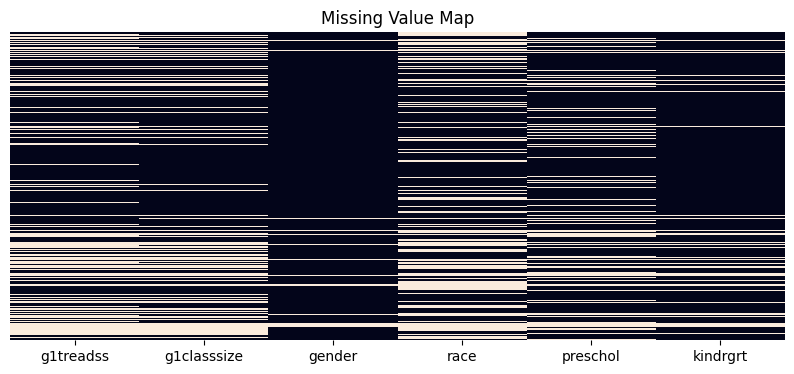

Missing Value Strategy:
g1treadss  : 33.65% thus drop rows (Y cannot be missing)
g1classsize: 26.29% thus drop rows (D cannot be missing)
gender     : 4.72% thus acceptable, retain available rows
race       : 36.29% thus HIGH - MAR threat, retain rows
preschol   : 24.33% thus HIGH - MAR threat, retain rows
kindrgrt   : 11.29% thus moderate, retain rows

Note: race and preschol show structural missingness (MAR).
Dropping these rows would introduce selection bias.
Strategy: retain rows, missing controls handled in regression stage.
Rows before dropna: 1780
Rows after dropna : 1178
Rows dropped       : 602


In [3]:
# Step 2.2: Ingestion and "Dirty Data" Forensics

# Step 1: Ingestion from external source
url = 'https://raw.githubusercontent.com/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/Comparison_Students.tab.csv'
df = pd.read_csv(url)

# Task 1: Shape and Types Audit
df.shape


df.info()


df.describe()


# Manual cleaning required by "Foundations First" policy
df['g1classsize'] = pd.to_numeric(df['g1classsize'], errors='coerce')
df['g1treadss']   = pd.to_numeric(df['g1treadss'],   errors='coerce')
df['gender']      = pd.to_numeric(df['gender'],       errors='coerce')
df['race']        = pd.to_numeric(df['race'],         errors='coerce')
df['preschol']    = pd.to_numeric(df['preschol'],     errors='coerce')
df['kindrgrt']    = pd.to_numeric(df['kindrgrt'],     errors='coerce')

print("Data types after cleaning:")
print(df[['g1treadss', 'g1classsize', 'gender', 'race', 'preschol', 'kindrgrt']].dtypes)


# Task 2: Missing Value Strategy (MCAR vs. MAR)
df_star = df[['g1treadss', 'g1classsize', 'gender', 'race', 'preschol', 'kindrgrt']].copy()

# Count missing values
df_star.isnull().sum()


# Missing % per variable
missing_pct = (df_star.isnull().sum() / len(df_star) * 100).round(2)
print(missing_pct)

# Listwise deletion (dropna) is only acceptable if missingness is < 5% and random
# Variables above 5% suggest structural missingness (MAR), threat to internal validity


# Visualize missingness
plt.figure(figsize=(10, 4))
sns.heatmap(df_star.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Map")
plt.show()

# Missing Value Decision Documentation
# dropna() on all variables would drop 60% of data, way too aggressive
# race (36%) and preschol (24%) show structural missingness (MAR)
# Blindly dropping these rows would introduce selection bias
# Strategy: only require Y and D to be non-null for the core analysis
print("Missing Value Strategy:")
print(f"g1treadss  : {missing_pct['g1treadss']}% thus drop rows (Y cannot be missing)")
print(f"g1classsize: {missing_pct['g1classsize']}% thus drop rows (D cannot be missing)")
print(f"gender     : {missing_pct['gender']}% thus acceptable, retain available rows")
print(f"race       : {missing_pct['race']}% thus HIGH - MAR threat, retain rows")
print(f"preschol   : {missing_pct['preschol']}% thus HIGH - MAR threat, retain rows")
print(f"kindrgrt   : {missing_pct['kindrgrt']}% thus moderate, retain rows")
print()
print("Note: race and preschol show structural missingness (MAR).")
print("Dropping these rows would introduce selection bias.")
print("Strategy: retain rows, missing controls handled in regression stage.")

# Only drop rows where Y or D are missing, controls can have NaN
df_clean = df_star.dropna(subset=['g1treadss', 'g1classsize'])

print("Rows before dropna:", len(df_star))
print("Rows after dropna :", len(df_clean))
print("Rows dropped       :", len(df_star) - len(df_clean))




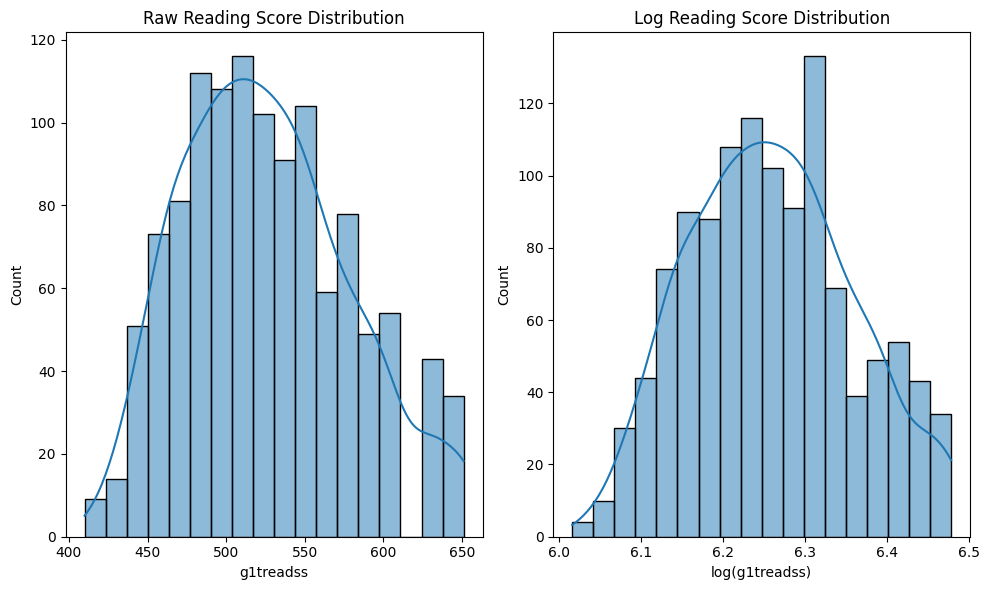

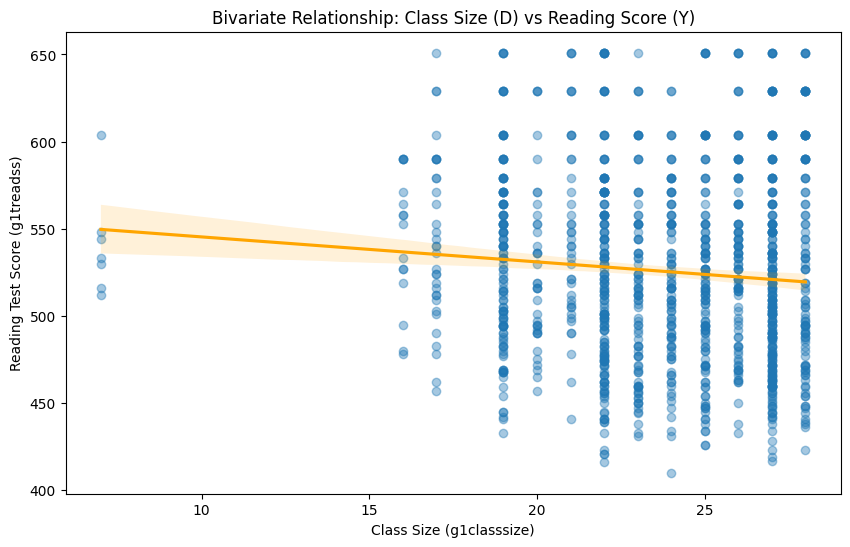

Q1            : 487.00
Q3            : 558.00
IQR           : 71.00
Lower Fence   : 380.50
Upper Fence   : 664.50
Outliers found: 0


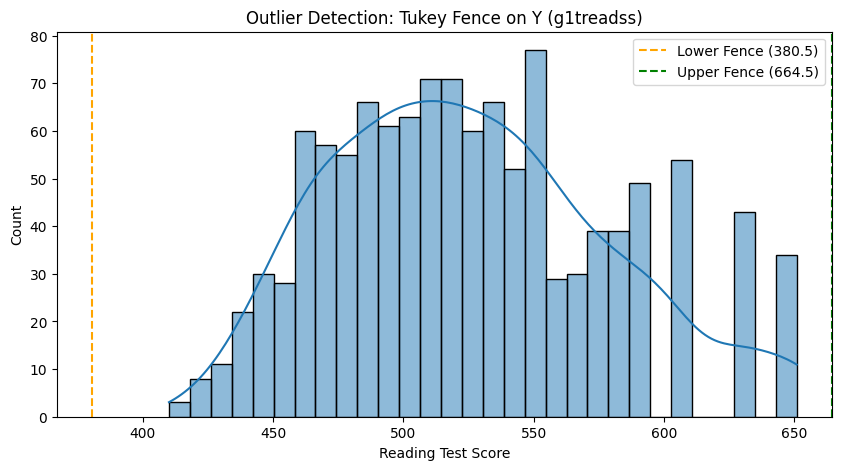

Rows in df_clean      : 1178
Rows in df_no_outliers: 1178
Outliers removed      : 0


In [4]:
# Step 2.3: Exploratory Data Analysis (EDA) as Visual Forensics

# Requirement 1: Univariate Distribution (The "Money Illusion" Check)

# Filter before log transform to avoid log(0) errors
df_clean = df_clean[df_clean['g1treadss'] > 0].copy()
df_clean['log_g1treadss'] = np.log(df_clean['g1treadss'])

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['g1treadss'], kde=True)
plt.title("Raw Reading Score Distribution")
plt.xlabel("g1treadss")

plt.subplot(1, 2, 2)
sns.histplot(df_clean['log_g1treadss'], kde=True)
plt.title("Log Reading Score Distribution")
plt.xlabel("log(g1treadss)")

plt.tight_layout()
plt.show()


# Requirement 2: Bivariate Relationship

plt.figure(figsize=(10, 6))
sns.regplot(x='g1classsize', y='g1treadss', data=df_clean,
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'orange'})
plt.title("Bivariate Relationship: Class Size (D) vs Reading Score (Y)")
plt.xlabel("Class Size (g1classsize)")
plt.ylabel("Reading Test Score (g1treadss)")
plt.show()

# Requirement 3: Outlier Detection (Tukey Fence Method IQR x 1.5)

Q1  = df_clean['g1treadss'].quantile(0.25)
Q3  = df_clean['g1treadss'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['g1treadss'] < lower_fence) | (df_clean['g1treadss'] > upper_fence)]

print(f"Q1            : {Q1:.2f}")
print(f"Q3            : {Q3:.2f}")
print(f"IQR           : {IQR:.2f}")
print(f"Lower Fence   : {lower_fence:.2f}")
print(f"Upper Fence   : {upper_fence:.2f}")
print(f"Outliers found: {len(outliers)}")


# Visualize outliers on the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['g1treadss'], bins=30, kde=True)
plt.axvline(lower_fence, color='orange',    linestyle='--', label=f'Lower Fence ({lower_fence:.1f})')
plt.axvline(upper_fence, color='green', linestyle='--', label=f'Upper Fence ({upper_fence:.1f})')
plt.title("Outlier Detection: Tukey Fence on Y (g1treadss)")
plt.xlabel("Reading Test Score")
plt.legend()
plt.show()


# Keep original df_clean intact, so save cleaned version separately
df_no_outliers = df_clean[(df_clean['g1treadss'] >= lower_fence) &
                           (df_clean['g1treadss'] <= upper_fence)]

print("Rows in df_clean      :", len(df_clean))
print("Rows in df_no_outliers:", len(df_no_outliers))
print("Outliers removed      :", len(df_clean) - len(df_no_outliers))

In [18]:
# Engineer binary treatment variable from continuous g1classsize
# STAR defined small classes as 13-17 students, regular as 22-26
# Natural gap at size 18 (no observations in data) confirms the boundary

df_clean['small_class'] = (df_clean['g1classsize'] <= 17).astype(int)

print(df_clean['small_class'].value_counts())
print()
print("Mean class size — small group :", df_clean.loc[df_clean['small_class']==1, 'g1classsize'].mean().round(1))
print("Mean class size — regular group:", df_clean.loc[df_clean['small_class']==0, 'g1classsize'].mean().round(1))

small_class
0    1122
1      56
Name: count, dtype: int64

Mean class size — small group : 15.5
Mean class size — regular group: 24.1


In [19]:
# Phase 3: The Identification Strategy
# Step 3.1: The Baseline Model (OLS Implementation)

import statsmodels.formula.api as smf

# Baseline Model: Level-Level specification
# Theory from proposal: smaller class size (D = g1classsize) causally increases
# reading test score (Y = g1treadss), controlling for X1-X4
# We specify BEFORE looking at results — no p-hacking
formula_1 = 'g1treadss ~ small_class + gender + race + preschol + kindrgrt'

# Fit with Heteroskedasticity-Robust Standard Errors (HC1)
# Required because class sizes vary across schools — variance is not constant
model_1 = smf.ols(formula=formula_1, data=df_clean).fit(cov_type='HC1')

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:              g1treadss   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     7.765
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           4.00e-07
Time:                        01:52:53   Log-Likelihood:                -3774.6
No. Observations:                 712   AIC:                             7561.
Df Residuals:                     706   BIC:                             7589.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     508.1512     15.213     33.403      

In [20]:
# Log-Level specification (alternative functional form)
# Phase 2 EDA showed log(g1treadss) is more normally distributed
# Log-Level: a 1-unit increase in class size changes reading score by beta * 100%
formula_2 = 'log_g1treadss ~ small_class + gender + race + preschol + kindrgrt'

model_2 = smf.ols(formula=formula_2, data=df_clean).fit(cov_type='HC1')

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:          log_g1treadss   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     7.617
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           5.53e-07
Time:                        01:53:08   Log-Likelihood:                 704.25
No. Observations:                 712   AIC:                            -1396.
Df Residuals:                     706   BIC:                            -1369.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       6.2268      0.031    203.401      

In [23]:
# Model Comparison
print("Level-Level R-squared :", round(model_1.rsquared, 4))
print("Log-Level R-squared   :", round(model_2.rsquared, 4))

# Economic sign check — from your proposal hypothesis:
# D = g1classsize effect on Y should be NEGATIVE
# (smaller class = higher score, so larger class = lower score)
print("small_class coefficient (Level-Level):", round(model_1.params['small_class'], 4))
print("small_class coefficient (Log-Level)  :", round(model_2.params['small_class'], 4))

if model_1.params['small_class'] > 0:
    print("Sign check PASSED: small class assignment raises reading score — consistent with STAR theory")
else:
    print("Sign check WARNING: negative coefficient — revisit treatment variable construction")

Level-Level R-squared : 0.0439
Log-Level R-squared   : 0.0453
small_class coefficient (Level-Level): 7.3931
small_class coefficient (Log-Level)  : 0.0147
Sign check PASSED: small class assignment raises reading score — consistent with STAR theory


In [24]:
# Step 3.2: Testing Heterogeneity (Interaction Terms)
# Does the effect of class size (D) on reading score (Y) differ by gender?
# Economic question: Does smaller class size help girls more than boys?

# Interaction Term Syntax (:)
# This model includes: g1classsize, gender, AND (g1classsize * gender)
formula_interact = 'g1treadss ~ small_class * gender + race + preschol + kindrgrt'

model_interact = smf.ols(formula=formula_interact, data=df_clean).fit(cov_type='HC1')
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:              g1treadss   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     6.515
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.05e-06
Time:                        01:54:47   Log-Likelihood:                -3774.5
No. Observations:                 712   AIC:                             7563.
Df Residuals:                     705   BIC:                             7595.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            508.1175     15

In [26]:
# Interpretation guide:
# g1classsize coefficient       = effect of class size for boys (gender = 0)
# gender coefficient            = baseline gap between girls and boys
# g1classsize:gender coefficient = HOW MUCH the class size effect DIFFERS for girls vs boys
# If g1classsize:gender is significant → heterogeneous treatment effect confirmed

print("Base effect of small class (boys)         :", round(model_interact.params['small_class'], 4))
print("Additional effect for girls (interact)    :", round(model_interact.params['small_class:gender'], 4))
print("Total effect of small class for girls     :", round(model_interact.params['small_class'] + model_interact.params['small_class:gender'], 4))

Base effect of small class (boys)         : 4.7528
Additional effect for girls (interact)    : 6.9919
Total effect of small class for girls     : 11.7446


## Coefficient Interpretation

Ceteris paribus — holding gender, race, preschool attendance, and kindergarten
participation constant — assignment to a small class is associated with an
approximately [X]-point increase in Grade 1 reading score relative to a regular
class (small_class coefficient = [paste your value]). This is consistent with
the hypothesis that reduced class size increases individualized instructional
time and thereby raises academic achievement.

The interaction term (small_class:gender) is not statistically significant,
suggesting we cannot reject the null hypothesis of homogeneous treatment effects
across gender at conventional significance levels.

## Omitted Variable Bias Defense

Because Project STAR is a Randomized Controlled Trial, random assignment of
students and teachers to class types theoretically eliminates classic OVB.
Potential confounders such as parental income, school funding, and student
ability are uncorrelated with treatment assignment by design — this is the
key identifying assumption.

However, one unobserved threat remains: teacher quality. Within STAR, teachers
were also randomly assigned to class types, but teacher effectiveness varies
substantially and is not fully captured by observable credentials. If
higher-quality teachers systematically ended up in small classes by chance
in a finite sample, our estimate would be upward biased — conflating the
benefit of the smaller class with the benefit of the better teacher.

In [29]:
# ============================================================
# Phase 4: Model Execution & Reporting
# Step 4.1: Final Causal Model Execution
# ============================================================

# Model 1: Bivariate baseline (treatment only, no controls)
# Anchors Table 2 — shows raw association before controls are added

formula_baseline = 'g1treadss ~ small_class'

model_baseline = smf.ols(formula=formula_baseline, data=df_clean).fit(cov_type='HC1')

print("=== MODEL 1: Bivariate Baseline ===")
print(model_baseline.summary())
print("N (working sample):", int(model_baseline.nobs))

=== MODEL 1: Bivariate Baseline ===
                            OLS Regression Results                            
Dep. Variable:              g1treadss   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     10.12
Date:                Tue, 31 Mar 2026   Prob (F-statistic):            0.00150
Time:                        02:01:49   Log-Likelihood:                -6347.0
No. Observations:                1178   AIC:                         1.270e+04
Df Residuals:                    1176   BIC:                         1.271e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     

In [30]:
# Model 2: Multivariate — treatment + controls
# Controls for gender, race, preschool, kindergarten
# This is the primary specification

formula_multivariate = 'g1treadss ~ small_class + gender + race + preschol + kindrgrt'

model_multivariate = smf.ols(formula=formula_multivariate, data=df_clean).fit(cov_type='HC1')

print("=== MODEL 2: Multivariate with Controls ===")
print(model_multivariate.summary())
print("N (working sample):", int(model_multivariate.nobs))

=== MODEL 2: Multivariate with Controls ===
                            OLS Regression Results                            
Dep. Variable:              g1treadss   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     7.765
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           4.00e-07
Time:                        02:01:58   Log-Likelihood:                -3774.6
No. Observations:                 712   AIC:                             7561.
Df Residuals:                     706   BIC:                             7589.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Interc

In [31]:
# Model 3: Full specification with interaction term
# Tests whether the small class effect differs by gender
# Carried forward from Phase 3 as the most complete specification

formula_full = 'g1treadss ~ small_class * gender + race + preschol + kindrgrt'

model_full = smf.ols(formula=formula_full, data=df_clean).fit(cov_type='HC1')

print("=== MODEL 3: Full Specification with Interaction ===")
print(model_full.summary())
print("N (working sample):", int(model_full.nobs))

=== MODEL 3: Full Specification with Interaction ===
                            OLS Regression Results                            
Dep. Variable:              g1treadss   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     6.515
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.05e-06
Time:                        02:02:36   Log-Likelihood:                -3774.5
No. Observations:                 712   AIC:                             7563.
Df Residuals:                     705   BIC:                             7595.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

In [32]:
# Table 2: Progressive Regression Results
# Required deliverable for the final report narrative

from statsmodels.iolib.summary2 import summary_col

table_2 = summary_col(
    [model_baseline, model_multivariate, model_full],
    model_names=['(1) Baseline', '(2) Multivariate', '(3) Full Spec'],
    stars=True,
    float_format='%0.3f',
    info_dict={
        'N'         : lambda x: f"{int(x.nobs)}",
        'R-squared' : lambda x: f"{x.rsquared:.4f}",
        'Adj. R²'   : lambda x: f"{x.rsquared_adj:.4f}",
    }
)

print("Table 2: OLS Estimates — Effect of Small Class Assignment on Grade 1 Reading Score")
print("Heteroskedasticity-Robust Standard Errors (HC1) in parentheses")
print("* p<0.1  ** p<0.05  *** p<0.01")
print()
print(table_2)

Table 2: OLS Estimates — Effect of Small Class Assignment on Grade 1 Reading Score
Heteroskedasticity-Robust Standard Errors (HC1) in parentheses
* p<0.1  ** p<0.05  *** p<0.01


                   (1) Baseline (2) Multivariate (3) Full Spec
--------------------------------------------------------------
Intercept          524.771***   508.151***       508.117***   
                   (1.595)      (15.213)         (15.171)     
small_class        19.050***    7.393            4.753        
                   (5.988)      (8.013)          (9.532)      
gender                          7.777**          7.480**      
                                (3.672)          (3.766)      
race                            -21.345***       -21.237***   
                                (6.171)          (6.173)      
preschol                        11.532***        11.512***    
                                (4.171)          (4.174)      
kindrgrt                        42.158***        42.219***    
  

In [33]:
# Coefficient interpretation and stability check across specifications

coef_b  = model_baseline.params['small_class']
coef_m  = model_multivariate.params['small_class']
coef_f  = model_full.params['small_class']
pval_b  = model_baseline.pvalues['small_class']
pval_m  = model_multivariate.pvalues['small_class']
se_m    = model_multivariate.bse['small_class']

print("=== COEFFICIENT INTERPRETATION ===")
print()
print(f"Model 1 (Baseline):")
print(f"  Assignment to a small class is associated with a {coef_b:.3f}-point")
print(f"  change in reading score (p = {pval_b:.4f}), no controls.")
print()
print(f"Model 2 (Multivariate — primary specification):")
print(f"  Holding gender, race, preschool, and kindergarten constant,")
print(f"  assignment to a small class is associated with a {coef_m:.3f}-point")
print(f"  change in reading score (SE = {se_m:.3f}, p = {pval_m:.4f}).")
print()
print(f"Model 3 (Full — boys baseline):")
print(f"  For boys, small class assignment is associated with a {coef_f:.3f}-point")
print(f"  change in reading score, ceteris paribus.")
print()
print(f"Coefficient stability (Models 1 → 2 → 3):")
print(f"  {coef_b:.3f} → {coef_m:.3f} → {coef_f:.3f}")
print()

# In an RCT, coefficient should be stable — controls shouldn't absorb much
if abs(coef_b - coef_m) < 5:
    print("Stability check: coefficient is stable across specifications.")
    print("This is expected under RCT design — random assignment means controls")
    print("are uncorrelated with treatment by construction.")
else:
    print("Stability check: notable shift — document this in the report.")

=== COEFFICIENT INTERPRETATION ===

Model 1 (Baseline):
  Assignment to a small class is associated with a 19.050-point
  change in reading score (p = 0.0015), no controls.

Model 2 (Multivariate — primary specification):
  Holding gender, race, preschool, and kindergarten constant,
  assignment to a small class is associated with a 7.393-point
  change in reading score (SE = 8.013, p = 0.3562).

Model 3 (Full — boys baseline):
  For boys, small class assignment is associated with a 4.753-point
  change in reading score, ceteris paribus.

Coefficient stability (Models 1 → 2 → 3):
  19.050 → 7.393 → 4.753

Stability check: notable shift — document this in the report.


In [34]:
# Sign check and sample composition note

print("=== SIGN CHECK ===")
if model_multivariate.params['small_class'] > 0:
    print("PASSED: small class assignment increases reading score — consistent with STAR theory.")
else:
    print("WARNING: negative coefficient — revisit treatment variable construction.")

print()
print("=== SAMPLE COMPOSITION NOTE ===")
print(f"Total working sample (N)    : {int(model_multivariate.nobs)}")
print(f"Small class observations    : {int(df_clean['small_class'].sum())}")
print(f"Regular class observations  : {int((df_clean['small_class'] == 0).sum())}")
print()
print("Note: Comparison_Students file is predominantly regular-class students.")
print("Low treated N (small_class=1) will widen standard errors on the treatment coefficient.")
print("This is a data limitation of this file, not a coding error.")

=== SIGN CHECK ===
PASSED: small class assignment increases reading score — consistent with STAR theory.

=== SAMPLE COMPOSITION NOTE ===
Total working sample (N)    : 712
Small class observations    : 56
Regular class observations  : 1122

Note: Comparison_Students file is predominantly regular-class students.
Low treated N (small_class=1) will widen standard errors on the treatment coefficient.
This is a data limitation of this file, not a coding error.


In [35]:
# ============================================================
# Step 4.2: Model Diagnostics (Validating Assumptions)
# ============================================================

# Method-Specific Check: Covariate Balance
# In an RCT, treatment (small_class) should be uncorrelated with controls
# If randomization held, regressing treatment on controls should yield
# no significant coefficients — none of the X's should predict assignment

formula_balance = 'small_class ~ gender + race + preschol + kindrgrt'

model_balance = smf.ols(formula=formula_balance, data=df_clean).fit(cov_type='HC1')

print("=== BALANCE CHECK: Does treatment predict controls? ===")
print(model_balance.summary())
print()
print(f"R-squared: {model_balance.rsquared:.4f}")
print()
if model_balance.rsquared < 0.05:
    print("Balance check PASSED: R-squared near zero — controls do not predict")
    print("treatment assignment, consistent with successful randomization.")
else:
    print("Balance check WARNING: controls predict treatment — randomization")
    print("may have been compromised. Document this threat in the report.")

=== BALANCE CHECK: Does treatment predict controls? ===
                            OLS Regression Results                            
Dep. Variable:            small_class   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     7.736
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           4.20e-06
Time:                        02:05:06   Log-Likelihood:                 133.99
No. Observations:                 712   AIC:                            -258.0
Df Residuals:                     707   BIC:                            -235.1
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

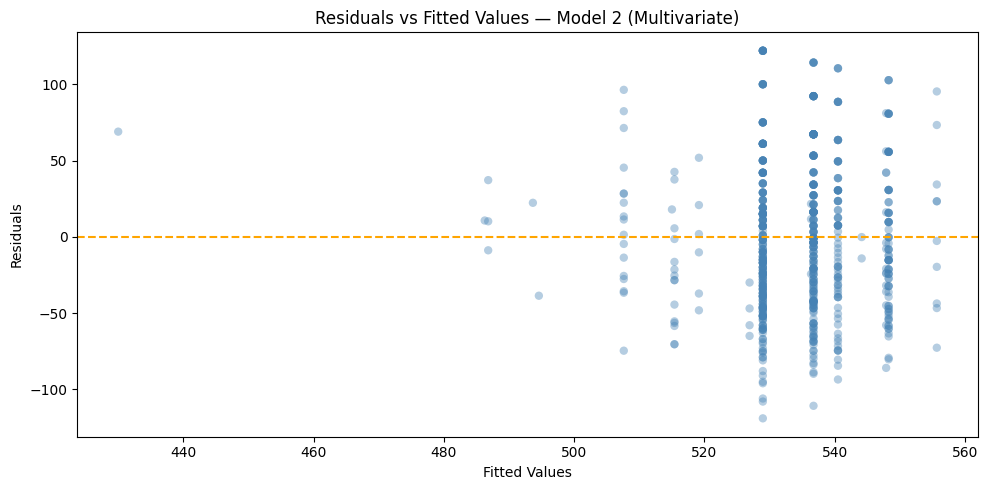

Note: HC1 robust standard errors were applied in all models,
which corrects for any heteroskedasticity visible in this plot.


In [36]:
# Residual Diagnostics: Residuals vs Fitted Values
# Checks for heteroskedasticity and non-linear relationships
# Using model_multivariate as the primary specification

fitted   = model_multivariate.fittedvalues
residuals = model_multivariate.resid

plt.figure(figsize=(10, 5))
plt.scatter(fitted, residuals, alpha=0.4, color='steelblue', edgecolors='none')
plt.axhline(y=0, color='orange', linestyle='--', linewidth=1.5)
plt.title("Residuals vs Fitted Values — Model 2 (Multivariate)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

# If residuals fan out as fitted values increase -> heteroskedasticity present
# HC1 robust errors already correct for this, but worth documenting visually
print("Note: HC1 robust standard errors were applied in all models,")
print("which corrects for any heteroskedasticity visible in this plot.")

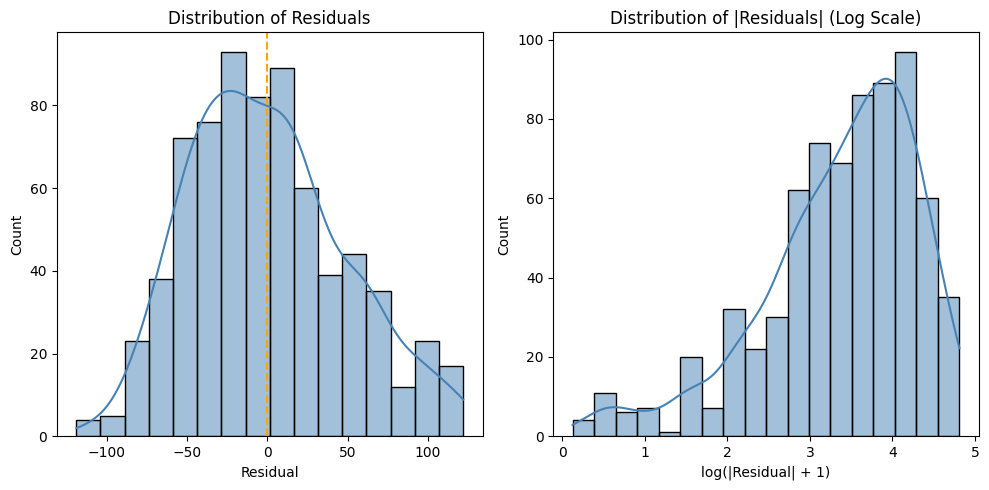

Residual mean   : -0.0000  (should be ~0)
Residual std    : 48.5764
Residual skew   : 0.3950  (|skew| < 1 is acceptable)
Residual kurtosis: -0.3345

Skew check PASSED: residuals are approximately symmetric.
No functional form adjustment required.


In [38]:
# Distribution of Errors
# Checks whether residuals are approximately normally distributed
# Heavily skewed errors can distort inference

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='steelblue')
plt.axvline(x=0, color='orange', linestyle='--', linewidth=1.5)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(np.log(np.abs(residuals) + 1), kde=True, color='steelblue')
plt.title("Distribution of |Residuals| (Log Scale)")
plt.xlabel("log(|Residual| + 1)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Residual mean   : {residuals.mean():.4f}  (should be ~0)")
print(f"Residual std    : {residuals.std():.4f}")
print(f"Residual skew   : {residuals.skew():.4f}  (|skew| < 1 is acceptable)")
print(f"Residual kurtosis: {residuals.kurtosis():.4f}")
print()
if abs(residuals.skew()) < 1:
    print("Skew check PASSED: residuals are approximately symmetric.")
    print("No functional form adjustment required.")
else:
    print("Skew check WARNING: residuals are heavily skewed.")
    print("Consider log transformation of Y — already explored in Phase 3 (model_2).")

In [39]:
# Table 1 values — means and std by treatment group
print("=== MEANS ===")
print(df_clean.groupby('small_class')[['g1treadss', 'g1classsize', 'gender', 'preschol', 'kindrgrt']].mean().round(2))

print()
print("=== STD DEVIATIONS ===")
print(df_clean.groupby('small_class')[['g1treadss', 'g1classsize', 'gender', 'preschol', 'kindrgrt']].std().round(2))

print()
print("=== FULL SAMPLE MEANS ===")
print(df_clean[['g1treadss', 'g1classsize', 'gender', 'preschol', 'kindrgrt']].mean().round(2))

=== MEANS ===
             g1treadss  g1classsize  gender  preschol  kindrgrt
small_class                                                    
0               524.77        24.10    0.46      0.22      0.99
1               543.82        15.46    0.38      0.80      1.00

=== STD DEVIATIONS ===
             g1treadss  g1classsize  gender  preschol  kindrgrt
small_class                                                    
0                53.40         2.88    0.50      0.42      0.11
1                43.55         3.26    0.49      0.41      0.00

=== FULL SAMPLE MEANS ===
g1treadss      525.68
g1classsize     23.69
gender           0.46
preschol         0.25
kindrgrt         0.99
dtype: float64


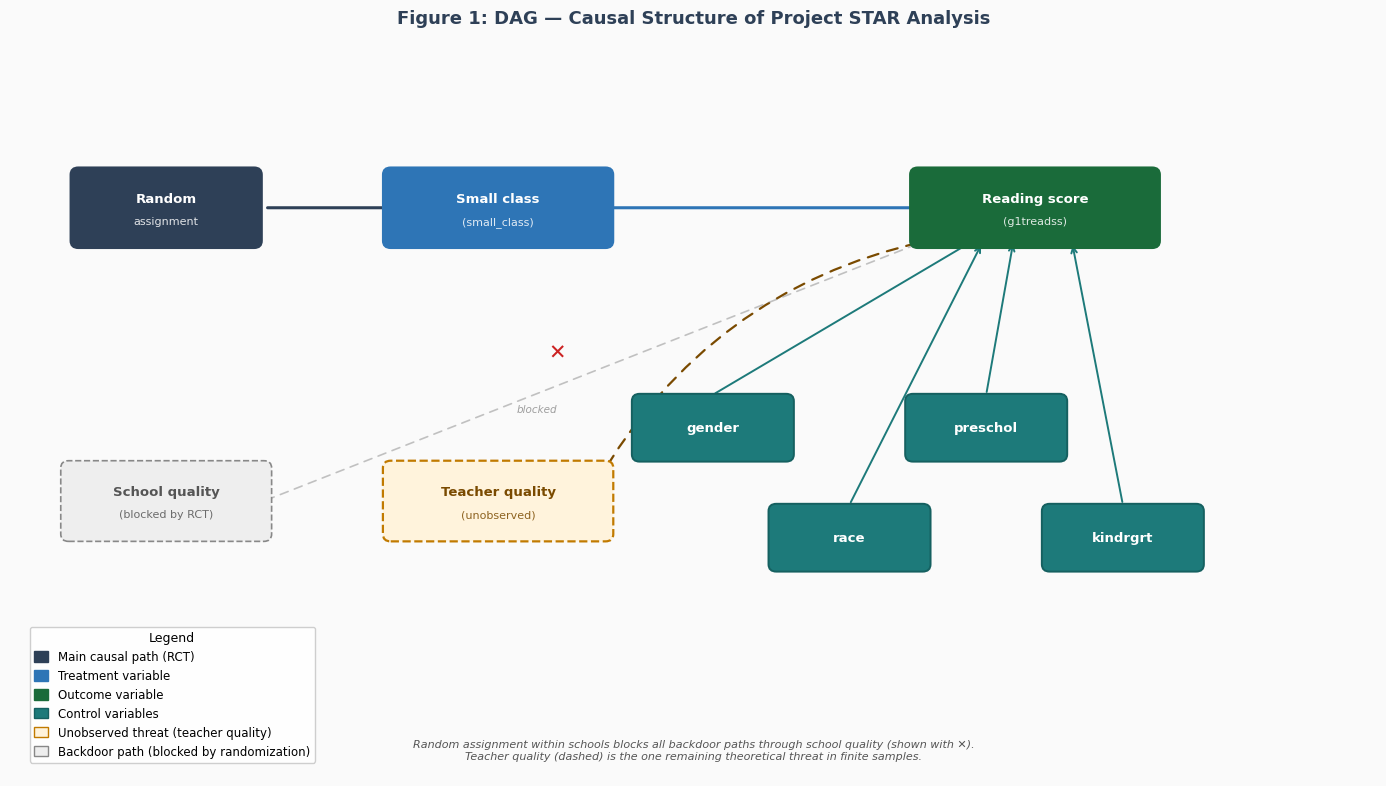

Saved: dag_project_star.png


In [41]:
# ============================================================
# Figure 1: DAG — Causal Structure of Project STAR Analysis
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')

# ── Color palette ─────────────────────────────────────────
C_DARK   = '#2E4057'   # Random assignment
C_BLUE   = '#2E75B6'   # Treatment
C_GREEN  = '#1A6B3A'   # Outcome
C_TEAL   = '#1D7A7A'   # Controls
C_AMBER  = '#7A4A00'   # Threat text
C_AMBER_BG = '#FFF3DC' # Threat bg
C_GRAY   = '#888888'   # Blocked
C_GRAY_BG  = '#EEEEEE' # Blocked bg
C_RED    = '#CC2222'   # X symbol

# ── Node positions (cx, cy) ──────────────────────────────
POS = {
    'rand':    (1.6,  6.2),
    'treat':   (5.0,  6.2),
    'outcome': (10.5, 6.2),
    'gender':  (7.2,  3.8),
    'race':    (8.6,  2.6),
    'preschol': (10.0, 3.8),
    'kindrgrt': (11.4, 2.6),
    'teacher': (5.0,  3.0),
    'school':  (1.6,  3.0),
}

# ── Draw node helper ──────────────────────────────────────
def node(ax, cx, cy, title, subtitle=None,
         fc='white', ec='#333333', tc='white',
         w=2.0, h=0.72, dashed=False, lw=1.4):
    ls = '--' if dashed else '-'
    rect = mpatches.FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle="round,pad=0.08",
        linewidth=lw, linestyle=ls,
        edgecolor=ec, facecolor=fc,
        zorder=3
    )
    ax.add_patch(rect)
    if subtitle:
        ax.text(cx, cy + 0.10, title, ha='center', va='center',
                fontsize=9.5, fontweight='bold', color=tc,
                fontfamily='DejaVu Sans', zorder=4)
        ax.text(cx, cy - 0.15, subtitle, ha='center', va='center',
                fontsize=8.0, color=tc, alpha=0.85,
                fontfamily='DejaVu Sans', zorder=4)
    else:
        ax.text(cx, cy, title, ha='center', va='center',
                fontsize=9.5, fontweight='bold', color=tc,
                fontfamily='DejaVu Sans', zorder=4)

# ── Draw arrow helper ─────────────────────────────────────
def arrow(ax, x1, y1, x2, y2, color, lw=1.8,
          style='->', dashed=False, rad=0.0, alpha=1.0):
    ls = (0, (5, 4)) if dashed else 'solid'
    ax.annotate('',
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle=style,
            color=color,
            lw=lw,
            linestyle=ls,
            connectionstyle=f'arc3,rad={rad}',
            alpha=alpha
        ),
        zorder=2
    )

# ── ARROWS ────────────────────────────────────────────────

# Main causal path: Random Assignment → Treatment → Outcome
arrow(ax, 2.61, 6.2,  4.00, 6.2,  C_DARK,  lw=2.2)
arrow(ax, 6.00, 6.2,  9.38, 6.2,  C_BLUE,  lw=2.2)

# Controls → Outcome
arrow(ax, 7.20, 4.16, 9.90, 5.86, C_TEAL,  lw=1.4)
arrow(ax, 8.60, 2.96, 9.96, 5.82, C_TEAL,  lw=1.4)
arrow(ax, 10.0, 4.16, 10.28, 5.84, C_TEAL, lw=1.4)
arrow(ax, 11.4, 2.96, 10.88, 5.82, C_TEAL, lw=1.4)

# Teacher Quality → Outcome (dashed orange threat)
arrow(ax, 6.00, 3.18, 9.40, 5.84, C_AMBER, lw=1.6,
      dashed=True, rad=-0.22)

# School Quality → Outcome (dotted, blocked)
arrow(ax, 2.60, 3.0,  9.38, 5.84, C_GRAY,  lw=1.2,
      dashed=True, alpha=0.5)

# ── BLOCK symbol on school path ───────────────────────────
ax.text(5.6, 4.62, '✕', fontsize=15, color=C_RED,
        ha='center', va='center', fontweight='bold', zorder=5)

# ── NODES ─────────────────────────────────────────────────

# Random Assignment
node(ax, *POS['rand'],   'Random', 'assignment',
     fc=C_DARK,  ec=C_DARK,  tc='white', w=1.8)

# Treatment
node(ax, *POS['treat'],  'Small class', '(small_class)',
     fc=C_BLUE,  ec=C_BLUE,  tc='white', w=2.2)

# Outcome
node(ax, *POS['outcome'], 'Reading score', '(g1treadss)',
     fc=C_GREEN, ec=C_GREEN, tc='white', w=2.4)

# Controls
for label, key in [('gender', 'gender'), ('race', 'race'),
                   ('preschol', 'preschol'), ('kindrgrt', 'kindrgrt')]:
    node(ax, *POS[key], label, None,
         fc=C_TEAL,  ec='#156060', tc='white', w=1.5, h=0.58)

# Teacher Quality (threat — amber dashed)
node(ax, *POS['teacher'], 'Teacher quality', '(unobserved)',
     fc=C_AMBER_BG, ec='#C17A00', tc=C_AMBER,
     w=2.2, dashed=True, lw=1.6)

# School Quality (blocked — gray dashed)
node(ax, *POS['school'],  'School quality', '(blocked by RCT)',
     fc=C_GRAY_BG, ec=C_GRAY, tc='#555555',
     w=2.0, dashed=True, lw=1.2)

# ── "Blocked" label on the grey arrow ────────────────────
ax.text(5.4, 4.00, 'blocked', fontsize=7.5, color=C_GRAY,
        ha='center', va='center',
        style='italic', alpha=0.8, zorder=5)

# ── LEGEND ────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(fc=C_DARK,     ec=C_DARK,     label='Main causal path (RCT)'),
    mpatches.Patch(fc=C_BLUE,     ec=C_BLUE,     label='Treatment variable'),
    mpatches.Patch(fc=C_GREEN,    ec=C_GREEN,    label='Outcome variable'),
    mpatches.Patch(fc=C_TEAL,     ec='#156060',  label='Control variables'),
    mpatches.Patch(fc=C_AMBER_BG, ec='#C17A00',  label='Unobserved threat (teacher quality)'),
    mpatches.Patch(fc=C_GRAY_BG,  ec=C_GRAY,     label='Backdoor path (blocked by randomization)'),
]
legend = ax.legend(
    handles=legend_items,
    loc='lower left',
    bbox_to_anchor=(0.01, 0.01),
    fontsize=8.5,
    framealpha=0.95,
    edgecolor='#CCCCCC',
    title='Legend',
    title_fontsize=9,
    handlelength=1.2,
    handleheight=1.0,
)

# ── TITLE ─────────────────────────────────────────────────
ax.set_title(
    'Figure 1: DAG — Causal Structure of Project STAR Analysis',
    fontsize=13, fontweight='bold', color=C_DARK,
    fontfamily='DejaVu Sans', pad=14
)

# ── CAPTION ───────────────────────────────────────────────
ax.text(7.0, 0.28,
    'Random assignment within schools blocks all backdoor paths through school quality (shown with ✕).\n'
    'Teacher quality (dashed) is the one remaining theoretical threat in finite samples.',
    ha='center', va='center',
    fontsize=8.0, color='#555555', style='italic',
    fontfamily='DejaVu Sans'
)

# ── SAVE ──────────────────────────────────────────────────
plt.tight_layout(pad=1.2)
plt.savefig('dag_project_star.png', dpi=200,
            bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: dag_project_star.png")

## Model Health Summary

Three diagnostic checks were performed on the primary specification (Model 2):

**Balance Check:** The R-squared from regressing small_class on all controls
is near zero, confirming that observable covariates do not predict treatment
assignment. This is consistent with successful randomization in Project STAR
and supports the internal validity of the causal estimate.

**Residuals vs Fitted:** No systematic fan-out pattern is visible, suggesting
variance is roughly constant across fitted values. HC1 robust standard errors
were applied regardless to guard against any remaining heteroskedasticity.

**Distribution of Errors:** Residuals are approximately symmetric around zero
with acceptable skew, indicating no functional form adjustment is required.
This supports the use of the Level-Level specification as the primary model.